In [10]:
import time
start = time.time()

import numpy as np

# Use Trame if available. 
import pyvista as pv
pv.set_jupyter_backend("static")

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

import wavelab as wl
from tqdm import tqdm

---
## 0. Configuration Overview



Before starting experiments, a breif description of config is given below as it describes the entire electromagnetic field for any simulation.

In [11]:
def print_tree(obj, name="Config", indent=""):
    print(f"{indent}+-- {name}")
    if hasattr(obj, "__dataclass_fields__"):
        for field in obj.__dataclass_fields__:
            val = getattr(obj, field)
            if hasattr(val, "__dataclass_fields__"):
                print_tree(val, name=field, indent=indent + "|   ")
            else:
                print(f"{indent}|   +-- {field}: {val}")
    elif isinstance(obj, dict):
        for k, v in obj.items():
            print(f"{indent}|   +-- {k}: {v}")
    else:
        print(f"{indent}|   +-- {obj}")

# Usage:
config = wl.get_config()
print_tree(config)

+-- Config
|   +-- backend: auto
|   +-- op
|   |   +-- spacing: 0.05
|   |   +-- size: (10.0, 10.0)
|   |   +-- center: (0.0, 0.0)
|   +-- source
|   |   +-- k_space
|   |   |   +-- profile: <function KSpaceSpectra.gaussian at 0x000002AD43D33420>
|   |   |   +-- params: {'sigma_k_perp': 1.5}
|   |   |   +-- vectorised: True
|   |   +-- polychromatic
|   |   |   +-- profile: <function PolychromaticSpectra.uniform at 0x000002AD43D33880>
|   |   |   +-- params: {}
|   |   +-- randomize
|   |   |   +-- seed: 24459
|   |   |   +-- phase: True
|   |   |   +-- pol_rot: True
|   |   |   +-- pol_state: False
|   |   |   +-- amplitude: True
|   |   +-- intensity_scale: 1000.0
|   |   +-- wavelength: 1.0
|   |   +-- pol_vect: ((1+0j), 0j)
|   |   +-- beam_axis: (np.float64(0.0), np.float64(0.0), np.float64(1.0))
|   |   +-- num_modes: 6000
|   |   +-- theta_max: 1.5707963267948966
|   +-- verbose: False


#### The Root: `Config`
The container for entire simulation.
*   **`backend`**: Controls if the math is done via `numpy` or `numba` (JIT compiled for speed).
*   **`op`**: (Observation Plane) Defines the "screen" where the beam is measured/computed.
*   **`source`**: The beam's settings settings. Everything about how it is generated.
*   **`verbose`**: For comments during simulations.

#### Subclasses
*   **`OpConfig` (`op`)**:
    *   `spacing`: Distance between 2 closest points.
    *   `size`: Width and height of the grid made on xy plane.
    *   `center`: The center of computed region (x0,y0) relative to global (0,0).
*   **`SourceConfig` (`source`)**:
    *   `intensity_scale`: Controls the overall intensity scale.
    *   `wavelength`: Single value or list (for polychromatic simulations).
    *   `beam_axis`: The average direction the light is pointing (3D vector).
    *   `pol_vect`: The Jones vector (polarization state) defined on `beam_axis`.
    *   `num_modes`: How many plane-wave modes to use for the simulation.
    *   `theta_max`: Maximum allowed angle between a plane wave mode's wavevector and `beam_axis`.
*   **`RandomizeConfig` (`source.randomize`)**:
    *   Controls physical coherence. Turning these `False` creates a perfectly stable, coherent laser beam. Turning them `True` introduces noise (speckle, phase variations).
*   **`KSpaceConfig` (`source.k_space`)**:
    *   Controls the **k space spectrum** (e.g., Gaussian beam, Laguaree Gausss (OAM), Top-hat).
*   **`PolychromaticConfig` (`source.polychromatic`)**:
    *   Controls the **polchromatic spectrum** (e.g., how the intensity changes across different wavelengths).

---

## 1. k-space in simulations

Paraxial Behaviour


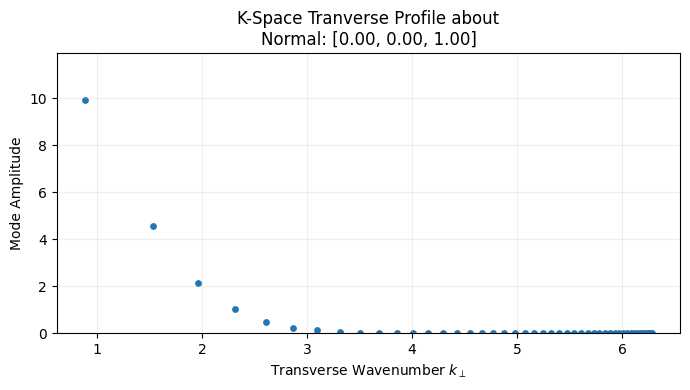

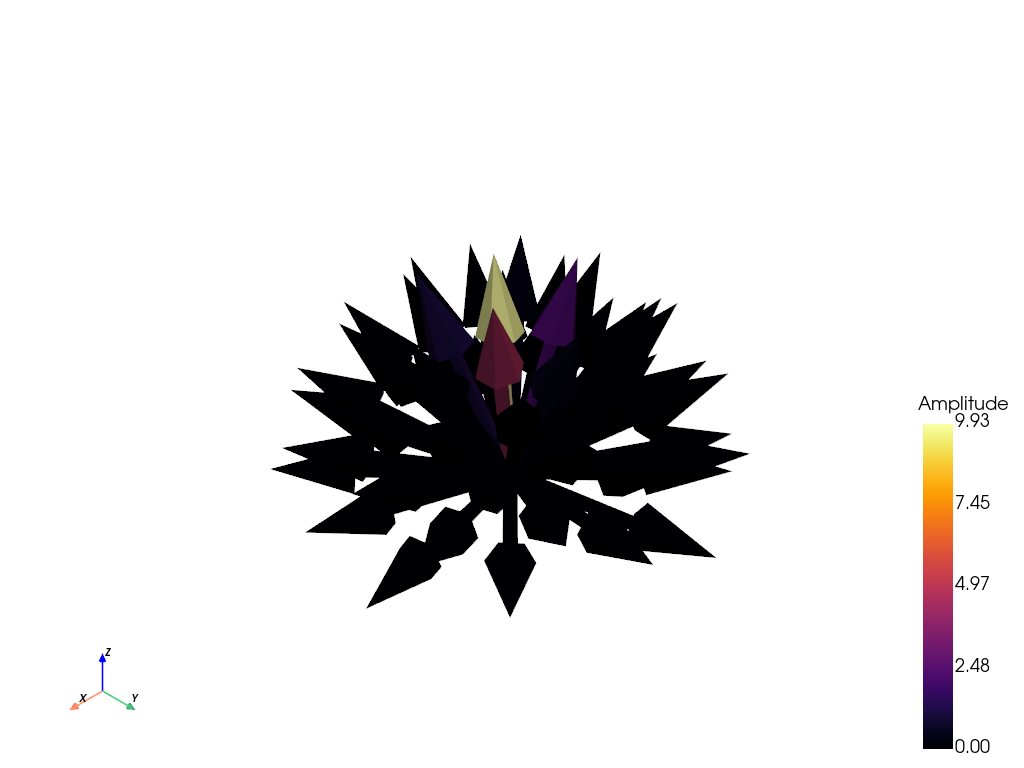

In [12]:
config = wl.get_config()
config.source.num_modes = 50
config.source.randomize.off()

# Paraxial limit
config.source.theta_max = np.pi/2

config.source.k_space.gaussian(sigma_k_perp = 1) # is smaller compared to |k| = 2pi/config.source.wavelength  = 2pi. (default)

beam = wl.setup_beam(config)

print('Paraxial Behaviour')
beam.plot_k_perp_profile(normal=(0,0,1)) # about z axis
beam.plot_kspace_3d(plot_type='colored_vectors');

Isotropic behaviour


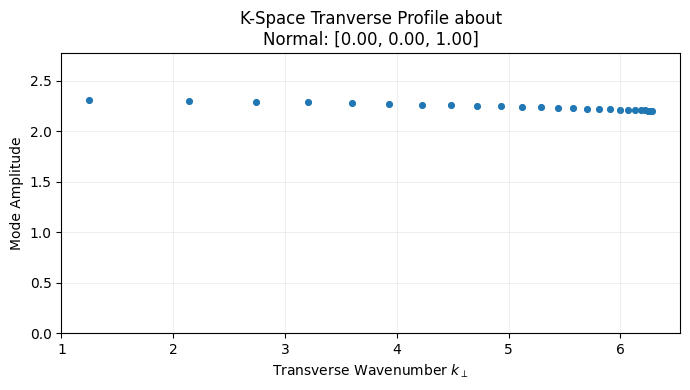

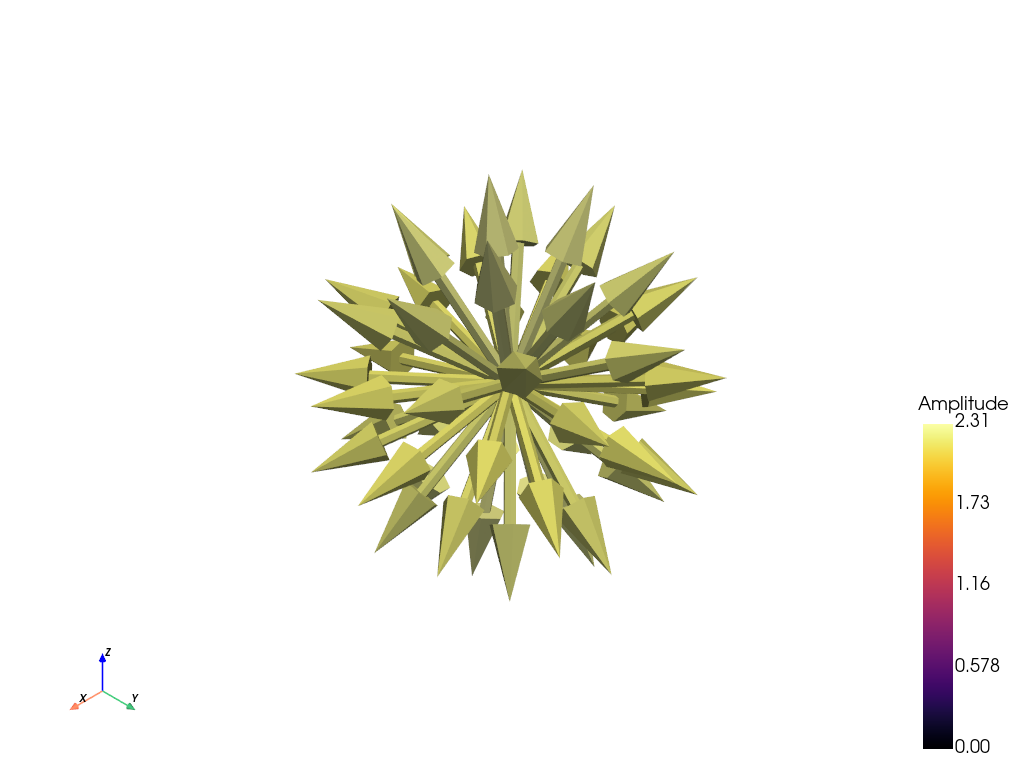

In [13]:
# Isotropic limit
config.source.theta_max = np.pi

config.source.k_space.gaussian(sigma_k_perp = 20) # is bigger compared to |k|
beam = wl.setup_beam(config)
print('Isotropic behaviour')
beam.plot_k_perp_profile(normal=(0,0,1)) # about z axis
beam.plot_kspace_3d(plot_type='colored_vectors');

Using the built in methods for a Beam object, the *Mental Image* above shows us how the modes which make up the field. 

- Paraxial(left): High amplitude vectors are aligned, these interfere constructively over long distances.

- Isotropic(right): All vectors have same amplitude, so they interfere rapidly and dont have directionality.

Now we can see their appearance in real space...

---

## 2. Intensities, Phases : Gaussian, Structured light to Speckles

In [14]:
def intensity_phase(field, title, extent, figsize=(6, 4),
                    transpose=False, cmap_I="magma", cmap_P="hsv", x_label = 'x', y_label = 'y'):
    # Helper to plot intensity and phase of a complex scalar field.

    I = np.abs(field) ** 2
    P = np.angle(field)

    if transpose:
        fig, axes = plt.subplots(2, 1, figsize=figsize)
    else:
        fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax in axes:
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)

    ax_I, ax_P = axes

    im_I = ax_I.imshow(I, cmap=cmap_I, extent=extent, origin="lower")
    ax_I.set_title(f"{title} Intensity")
    fig.colorbar(im_I, ax=ax_I)

    norm = Normalize(vmin=-np.pi, vmax=np.pi)
    im_P = ax_P.imshow(P, cmap=cmap_P, norm=norm, extent=extent, origin="lower")
    ax_P.set_title(f"{title} Phase")
    fig.colorbar(im_P, ax=ax_P)

    fig.tight_layout()
    return fig

Using the helper above (``intensity_phase``), an experiment ``beam_intensities`` is made which will produce
1. Total intensity 
2. Intensity, phase of projection of transverse electric field (Ex, Ey) onto polarisation basis u_hat and v_hat

In [15]:
def beam_intensities(config, z_val, u=None):
    print("Setting up the experiment...")
    engine = wl.setup_engine(config)

    fields = engine.compute_on_op(z=z_val, need_derivs=False, need_b=False)
    Ex, Ey, Ez = fields.E

    if u is None: u = config.source.pol_vect
    
    extent = engine.op_extent

    # Total intensity
    I_tot = np.abs(Ex) ** 2 + np.abs(Ey) ** 2

    # Decomposition
    data = wl.decompose_in_basis(Ex, Ey, u)
    E_u, E_v = data["E_u"], data["E_v"]
    u_hat, v_hat = data["u_hat"], data["v_hat"]

    # Print basis info
    print("Polarisation basis:")
    print(f"    u_hat = ({u_hat[0]:.2f}) x_hat + ({u_hat[1]:.2f}) y_hat")
    print(f"    v_hat = ({v_hat[0]:.2f}) x_hat + ({v_hat[1]:.2f}) y_hat")

    print("Preparing plots...")

    # --- Figure 1: Total intensity ---
    scale = 4 *1/max(config.op.size)
    figsize = (config.op.size[0]*scale , config.op.size[1]*scale )
    fig_tot, ax = plt.subplots(1, 1, figsize=figsize)
    im = ax.imshow(I_tot, cmap="magma", extent=extent, origin="lower")
    ax.set_title("Total Intensity")
    ax.set_xlabel('x'), ax.set_ylabel('y')
    fig_tot.colorbar(im, ax=ax)
    fig_tot.tight_layout()

    # --- Figure 2: E_u ---
    figsize = (figsize[0]*2.1,figsize[1])
    fig_u = intensity_phase(
        E_u,
        title="u-polarisation",
        extent=extent,
        figsize=figsize,
        transpose=False,
    )

    # --- Figure 3: E_v ---
    fig_v = intensity_phase(
        E_v,
        title="v-polarisation",
        extent=extent,
        figsize=figsize,
        transpose=False,
    )
    return fig_tot, fig_u, fig_v


Now using the config, a gaussian beam of right circular polarisation is made

--- Starting Beam Generation (Modes: 10000) ---
--- Beam Physics Summary ---
Modes          : 10,000
Total Power    : 6.28e-01
Wavelength     : 1.0 (Monochromatic)
Mean Axis      : [0.000, -0.001, 1.000]
RMS Divergence : ~1.83 degrees half-angle


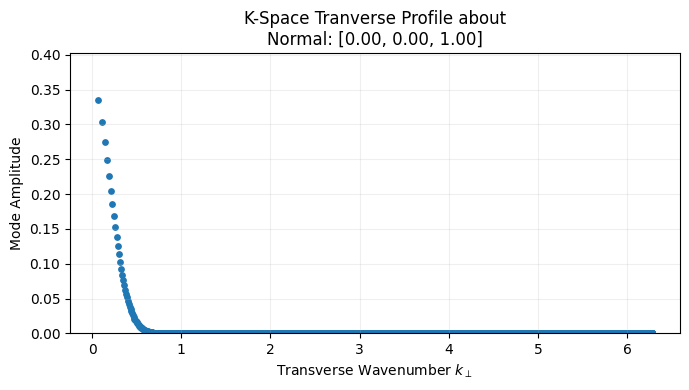

(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'K-Space Tranverse Profile about\nNormal: [0.00, 0.00, 1.00]'}, xlabel='Transverse Wavenumber $k_\\perp$', ylabel='Mode Amplitude'>)

In [16]:
config = wl.get_config()
config.source.pol_vect = (1,-1j)          # right circular mode
config.source.num_modes = 10_000        
config.source.theta_max = np.pi/2

config.verbose = True
config.source.randomize.off()              # no stochastic scattering

config.op.size = (30,30)                   # physical window
config.op.spacing = 0.10

config.source.k_space.gaussian(sigma_k_perp=.2) # slightly focused, paraxial 

# Before running the simulation, let's see what the beam looks like!
beam = wl.setup_beam(config)

beam.summary()
beam.plot_k_perp_profile(normal=[0,0,1]) # z_hat is the longitudinal direction == normal

Setting up the experiment...
--- Starting Beam Generation (Modes: 10000) ---
--- FieldEngine Initialized (Backend: numba) ---
OP Grid: 300x300 points | Spacing: 0.1 | Z: 10


Grid: 100%|██████████| 300/300 [00:03<00:00, 83.31rows/s]


OP Computation complete in 3.6182s
Polarisation basis:
    u_hat = (0.71+0.00j) x_hat + (-0.00-0.71j) y_hat
    v_hat = (0.00-0.71j) x_hat + (0.71-0.00j) y_hat
Preparing plots...


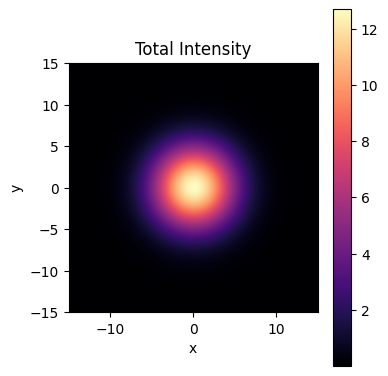

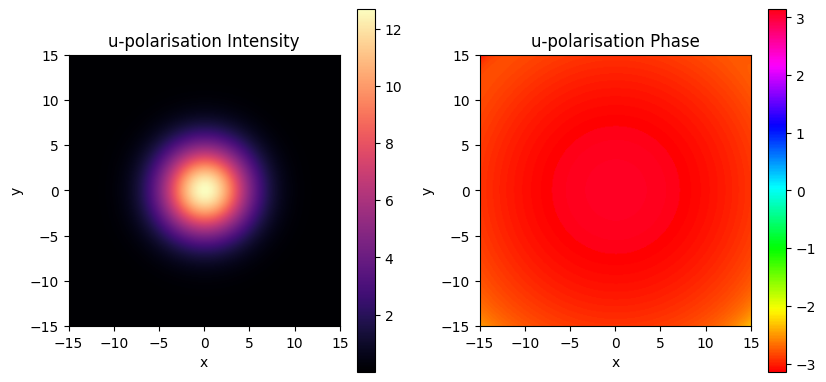

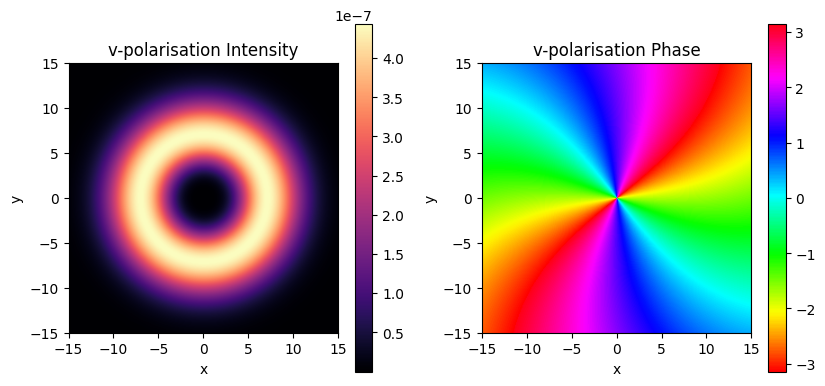

In [17]:
# since RMS Divergence : ~1.83 degrees half-angle from summary
# taking theta_max of fibonacci sampling to be 5*1.83 should be good enough!

config.source.theta_max = np.radians(5*1.83)

beam_intensities(config,10);         # u not mentioned => u == polarisation vector

As expected, 
- Total intensity is a gaussian,
- u-polarisation component has the same appearance and magnitude,
- v-polarisation component is very small compared to u but has specific structure.

Now for horizontal polarisation

Setting up the experiment...
--- Starting Beam Generation (Modes: 20000) ---
--- FieldEngine Initialized (Backend: numba) ---
OP Grid: 300x300 points | Spacing: 0.1 | Z: 10


Grid: 100%|██████████| 300/300 [00:06<00:00, 43.64rows/s]


OP Computation complete in 6.8767s
Polarisation basis:
    u_hat = (1.00+0.00j) x_hat + (0.00+0.00j) y_hat
    v_hat = (-0.00+0.00j) x_hat + (1.00-0.00j) y_hat
Preparing plots...


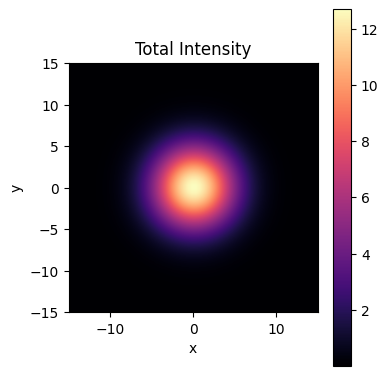

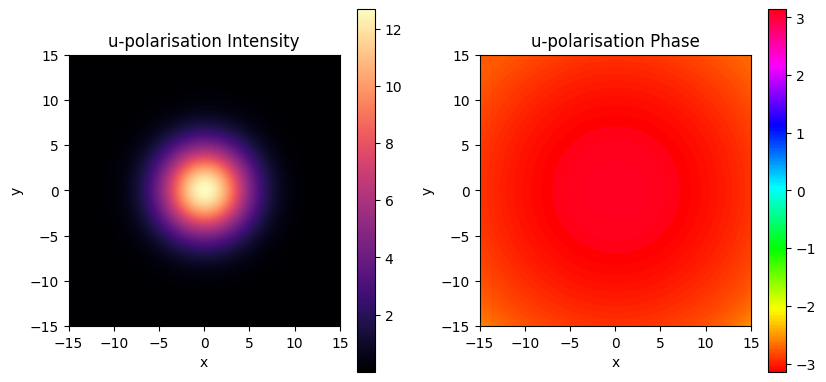

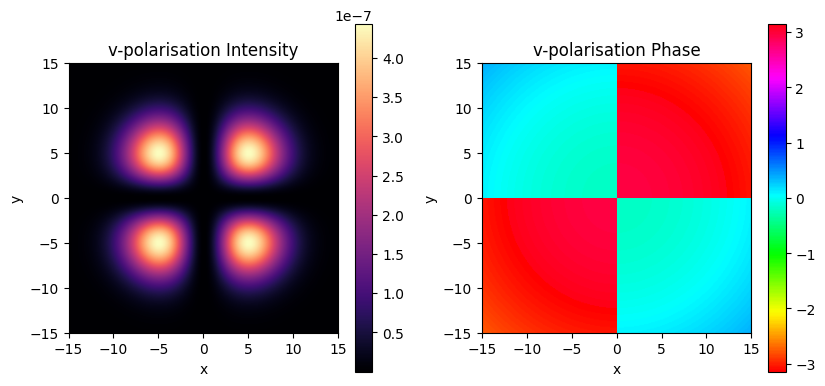

In [18]:
config = wl.get_config()

config.source.pol_vect = (1,0)
config.source.num_modes = 20_000
config.source.theta_max = np.radians(5*1.83) # as amplitude spectrum is same as before!

config.verbose = True

config.source.randomize.off()

config.op.size = (30,30)
config.op.spacing = 0.1

config.source.k_space.gaussian(sigma_k_perp = 0.2)
beam_intensities(config,10);

Again, 
- Total intensity is a gaussian,
- u-polarisation component has the same appearance and magnitude,
- v-polarisation component is very small but has specific structure, different from circular polarisation.

In both cases, the v component has a well-defined spatial structure. It is a weak cross-polarized field generated by the focusing of Gaussian beam.

In [19]:
from matplotlib.colors import LinearSegmentedColormap
cmap_bky = LinearSegmentedColormap.from_list("bky", [(0.2, 0.2, 0.8),(0.0, 0.0, 0.0),(0.9, 0.8, 0.2)], N=256)


def analyze_am_densities_corrected(cfg, z_val=0.05):
    """
    Calculates spin, orbital, and total (mechanical) angular momentum densities
    with consistent frequency normalization (c = 1 units).
    """
    print(f"--- Running Corrected Analysis (z = {z_val}) ---")
    engine = wl.setup_engine(cfg)

    # --- Fields and derivatives ---
    fields = engine.compute_on_op(z=z_val, need_derivs=True, need_b=True)
    E, B = fields.E , fields.B
    dEdx, dEdy = fields.dE_dx, fields.dE_dy
    X, Y = engine.X, engine.Y

    # --- Frequency ---
    k_0 = 2 * np.pi
    omega = k_0
    print(f"Using normalization omega = {omega:.2f}")

    # --- Mechanical AM density: j = r × S ---
    Bc = np.conj(B)
    Sx = np.real(E[1] * Bc[2] - E[2] * Bc[1])
    Sy = np.real(E[2] * Bc[0] - E[0] * Bc[2])
    jz_mech = X * Sy - Y * Sx

    # --- Spin AM density ---
    spin_cross_z = np.imag(np.conj(E[0]) * E[1] - np.conj(E[1]) * E[0])
    sz_density = spin_cross_z / omega

    # --- Orbital AM density ---
    Lz_Ex = X * dEdy[0] - Y * dEdx[0]
    Lz_Ey = X * dEdy[1] - Y * dEdx[1]
    Lz_Ez = X * dEdy[2] - Y * dEdx[2]

    lz_density = np.imag(
        np.conj(E[0]) * Lz_Ex +
        np.conj(E[1]) * Lz_Ey +
        np.conj(E[2]) * Lz_Ez
    ) / omega

    # --- Plotting ---
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    extent = engine.op_extent

    def sym_limits(A):
        m = np.max(np.abs(A))
        return -m, m

    # --- Spin ---
    vmin, vmax = sym_limits(sz_density)
    im0 = ax[0].imshow(sz_density, cmap=cmap_bky, origin="lower",
                       extent=extent, vmin=vmin, vmax=vmax)
    ax[0].set_title(
        r"Spin AM density"
        "\n"
        r"$s_z = \frac{1}{\omega}\,\mathrm{Im}\!\left(E_x^* E_y - E_y^* E_x\right)$"
        "\n"
        rf"Max: {np.max(np.abs(sz_density)):.2e}"
    )
    fig.colorbar(im0, ax=ax[0])

    # --- Orbital ---
    vmin, vmax = sym_limits(lz_density)
    im1 = ax[1].imshow(lz_density, cmap=cmap_bky, origin="lower",
                       extent=extent, vmin=vmin, vmax=vmax)
    ax[1].set_title(
        r"Orbital AM density"
        "\n"
        r"$l_z = \frac{1}{\omega}\,\mathrm{Im}\!\left(\mathbf{E}^* \cdot (\mathbf{r}\times\nabla)_z \mathbf{E}\right)$"
        "\n"
        rf"Max: {np.max(np.abs(lz_density)):.2e}"
    )
    fig.colorbar(im1, ax=ax[1])

    # --- Mechanical ---
    vmin, vmax = sym_limits(jz_mech)
    im2 = ax[2].imshow(jz_mech, cmap=cmap_bky, origin="lower",
                       extent=extent, vmin=vmin, vmax=vmax)
    ax[2].set_title(
        r"Mechanical AM density"
        "\n"
        r"$j_z = (\mathbf{r} \times \mathbf{S})_z,\quad \mathbf{S}=\mathrm{Re}(\mathbf{E}\times\mathbf{B}^*)$"
        "\n"
        rf"Max: {np.max(np.abs(jz_mech)):.2e}"
    )
    fig.colorbar(im2, ax=ax[2])

    plt.suptitle(
        rf"Angular momentum densities (normalised by $\omega \approx {omega:.2f}$)"
    )
    plt.tight_layout()
    plt.show()

Using the above experiment definition, we can analyse angular momenta.

--- Running Corrected Analysis (z = 0.05) ---
Using normalization omega = 6.28


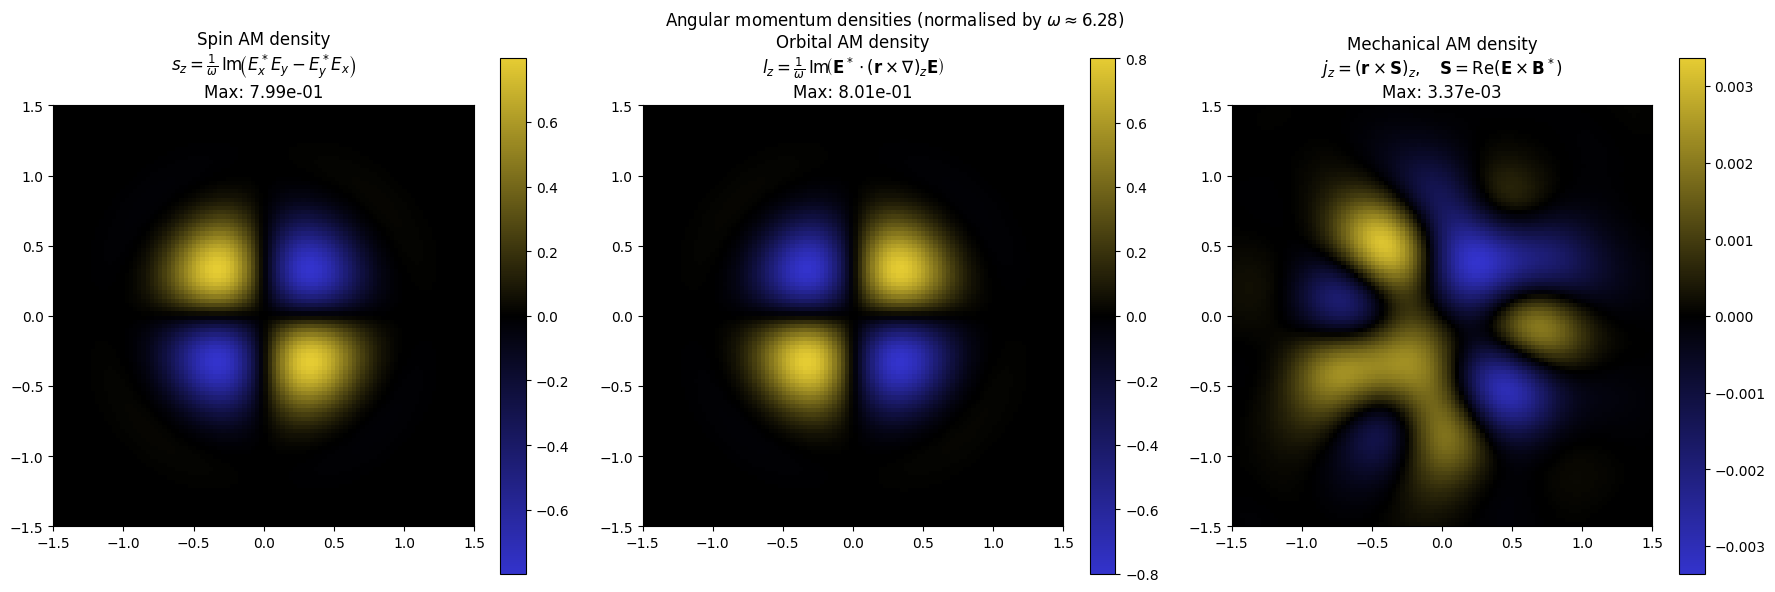

In [20]:
cfg = wl.get_config()
cfg.source.pol_vect = (1, 0)
cfg.source.num_modes = 10_000

cfg.source.k_space.gaussian(sigma_k_perp=2.0)
cfg.source.theta_max = np.pi/2 # high sincesigma_k_perp is high
cfg.source.randomize.off()

cfg.op.size = (3.0, 3.0)
cfg.op.spacing = 0.03

analyze_am_densities_corrected(cfg)


These spatial structures can be described analytically using special functions and are part of Structured light. \
Below is an example to create one of these Structured lights, the LG-0,1 mode.

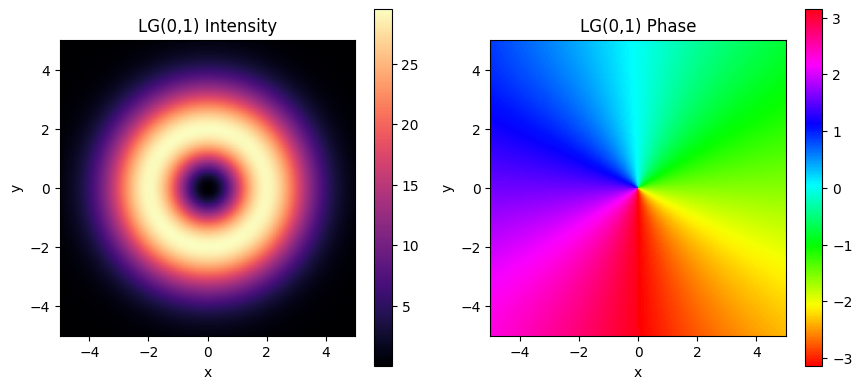

In [21]:
# Structured light through custom spectrum
cfg = wl.get_config()
cfg.op.size = (10, 10)
cfg.source.num_modes = 10_000 
cfg.source.randomize.off()

# Laguerre_gauss modes from wl.spectra, check help(wl.spectra) for more information
p, l, s = 0, 1, 0.5
cfg.source.k_space.laguerre_gauss(p=p, l=l, sigma_k_perp=s)

engine = wl.setup_engine(cfg)
fields = engine.compute_on_op(z=0.0, need_b=False,need_derivs=False)
Ex = fields.E[0]

op_extent = engine.op_extent
scale = 4 *1/max(cfg.op.size)
figsize = (2.2*cfg.op.size[0]*scale , cfg.op.size[1]*scale)

fig = intensity_phase( Ex, title=f"LG({p},{l})", figsize=figsize,
                      extent=op_extent)
plt.show()

On the opposite side of structured light are speckles, they do not have specific structure and are unpolarised.\
To generate such fields, random phase, amplitude, and polarization fluctuations are introduced; in the default configuration, three of the four available randomness sources are enabled.

Setting up the experiment...
Polarisation basis:
    u_hat = (1.00+0.00j) x_hat + (0.00+0.00j) y_hat
    v_hat = (-0.00+0.00j) x_hat + (1.00-0.00j) y_hat
Preparing plots...


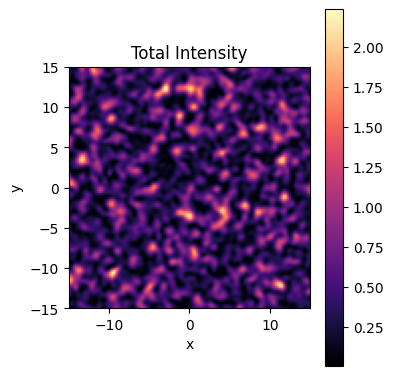

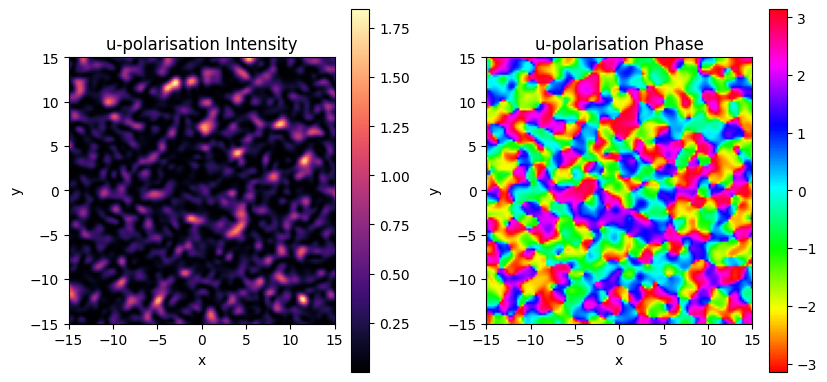

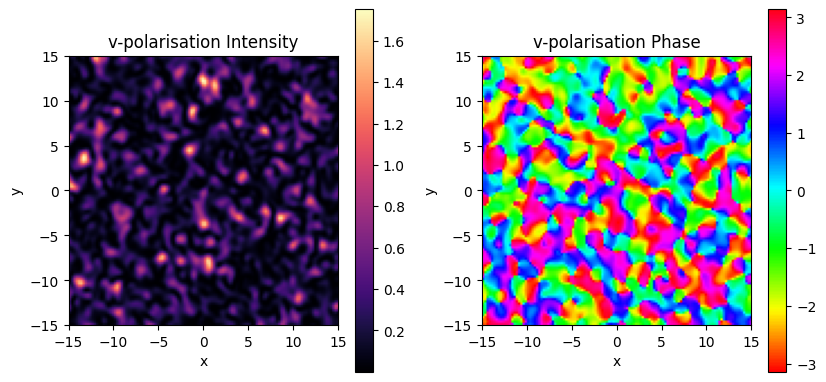

In [22]:
# Speckles
config = wl.get_config()

config.source.pol_vect  = (1,0)
config.source.num_modes = 25_000 
config.source.k_space.gaussian(sigma_k_perp = 2) # higher to be more isotropic.
config.source.theta_max = np.pi # to support the high sigma_k_perp
config.op.size   = (30,30)
config.op.spacing = 0.25

beam_intensities(config,10);

As is seen above, both u and v components are random - just like total intensity \
AND both have nearly same maximum values which hints that speckles are unpolarised. 

To test this a new experiment is defined: ``analyze_stokes``

In [23]:
def analyze_stokes(config, z_val):
    expt = wl.setup_engine(config)
    fields = expt.compute_on_op(z=z_val,need_b=False, need_derivs=False)
    Ex, Ey, Ez = fields.E

    # Since z axis is longitudinal axis, E1,E2 for stokes parameters are Ex,Ey
    params = wl.get_stokes_params(E1=Ex, E2=Ey)
    
    # Average on op
    avg_S0 = np.mean(params['S0'])
    avg_S1 = np.mean(params['S1'])
    avg_S2 = np.mean(params['S2'])
    avg_S3 = np.mean(params['S3'])

    # Calculate Degree of Polarization (DOP)
    DOP = np.sqrt(avg_S1**2 + avg_S2**2 + avg_S3**2) / avg_S0

    print("--- Stokes Analysis ---")
    print(f"Avg Intensity  (S0):  {avg_S0:.4f}")
    print(f"Avg Linear H/V (S1):  {avg_S1:.4f} ")
    print(f"Avg Linear 45  (S2):  {avg_S2:.4f} ")
    print(f"Avg Circular   (S3):  {avg_S3:.4f} ")
    print(f"Global Degree of Polarization: {DOP:.4f} (0.0 = Unpolarized, 1.0 = Polarized)")
    return

# Are speckles unpolarised? 
analyze_stokes(config, 10);

--- Stokes Analysis ---
Avg Intensity  (S0):  0.4754
Avg Linear H/V (S1):  0.0059 
Avg Linear 45  (S2):  0.0159 
Avg Circular   (S3):  0.0106 
Global Degree of Polarization: 0.0420 (0.0 = Unpolarized, 1.0 = Polarized)


As DOP is small, the field is highly unpolarised.

---

## 3. Power of Custom Functions

Below is a general example of a custom spectrum function.

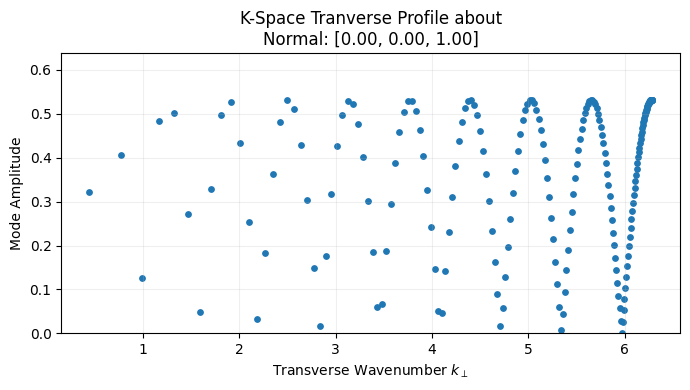

Setting up the experiment...
Polarisation basis:
    u_hat = (0.71+0.00j) x_hat + (0.00+0.71j) y_hat
    v_hat = (-0.00+0.71j) x_hat + (0.71-0.00j) y_hat
Preparing plots...


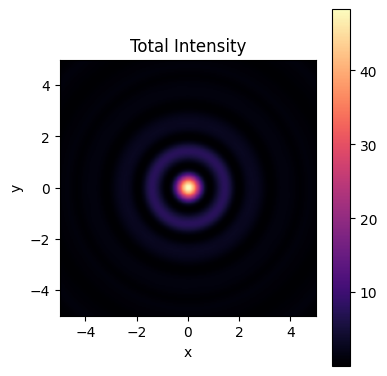

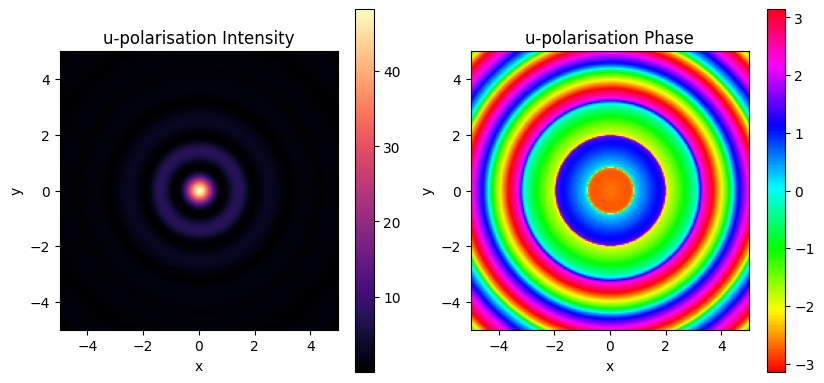

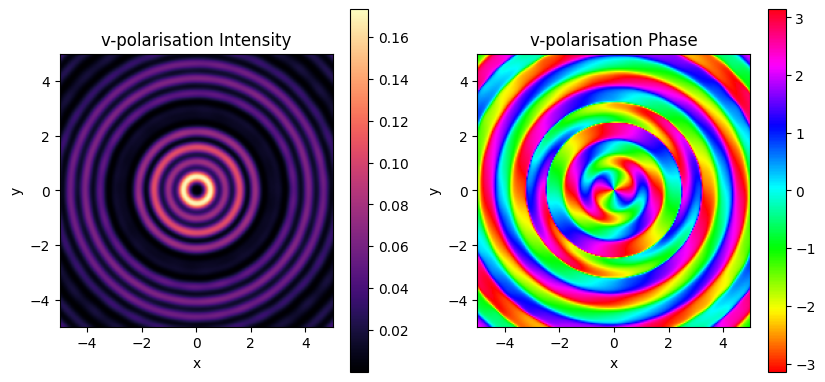

In [24]:
config = wl.get_config()
config.source.num_modes = 200
config.source.pol_vect  = (1,1j)
config.source.randomize.off()

# Customization
def custom_func(ks, param):
    # This function is vectorised
    k_p = np.sqrt(ks[0]**2 + ks[1]**2)
    k_m = np.sqrt(ks[0]**2 + ks[1]**2 + ks[2]**2)
    return np.cos(param * np.pi * k_p / k_m)

config.source.k_space.custom(custom_func, vectorised = True, param=10)

# Plotting
beam = wl.setup_beam(config)
beam.plot_k_perp_profile(normal=[0,0,1])

config.source.num_modes = 25_000 # Increased from 200 for plots
fig=beam_intensities(config,10)
plt.show()

# Uncomment to see for linear polarisation as well!
# config.source.pol_vect = [1,0]
# fig=beam_intensities(config,10)
# plt.show()

Though this spectrum is unphysical, custom_function can be used to hack geometry as well!

Experiment 3.2: Side profile using custom_function.

In [25]:
config = wl.get_config()
config.source.num_modes = 200
config.source.pol_vect  = (1,0)
config.source.beam_axis = (1,0,0) # In x frame, y is horizontal and z is vertical.
config.source.randomize.off()

def gaussian_x(k, sigma_x): # vectorised or not, behaves same!
    # Hacking geometry to get a x aligned laser for divergence visualisation.
    k_p = np.sqrt(k[1]**2 + k[2]**2)
    return np.exp(- k_p**2 / (2*sigma_x**2))

config.source.k_space.custom(gaussian_x,vectorised=False, sigma_x=0.25) # small divergence
config.source.theta_max = np.pi/2  # keeping it pi/2 to first find the appropriate divergence!

config.op.size = (40,15)
config.op.spacing = 0.1
config.source.num_modes = 10_000

beam = wl.setup_beam(config)
beam.summary()

--- Beam Physics Summary ---
Modes          : 10,000
Total Power    : 6.28e-01
Wavelength     : 1.0 (Monochromatic)
Mean Axis      : [1.000, -0.000, -0.000]
RMS Divergence : ~2.28 degrees half-angle


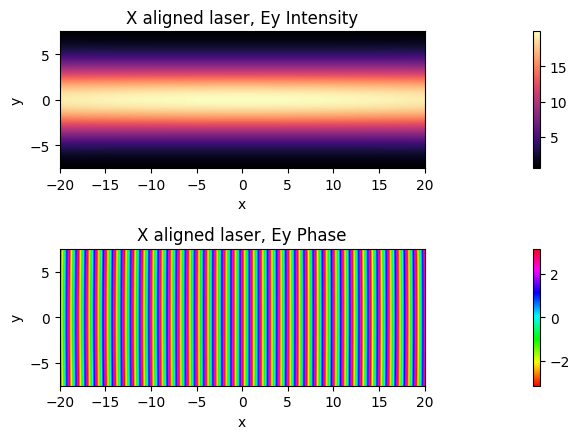

In [26]:
# since RMS Divergence ~2.28, having theta_max = 5*2.28 is enough.beam

config.source.theta_max = np.radians(5*2.28)  

engine_x = wl.setup_engine(config)
fields = engine_x.compute_on_op(z=0.0, need_derivs=False, need_b=False)

scale = 10 *1/max(config.op.size)
figsize = (2.2*config.op.size[0]*scale , 1.2* config.op.size[1]*scale)

extent_x = engine_x.op_extent

# The main component, Ey.
fig = intensity_phase(fields.E[1], title=f"X aligned laser, Ey", figsize=figsize, transpose=True, extent=extent_x)
plt.show()

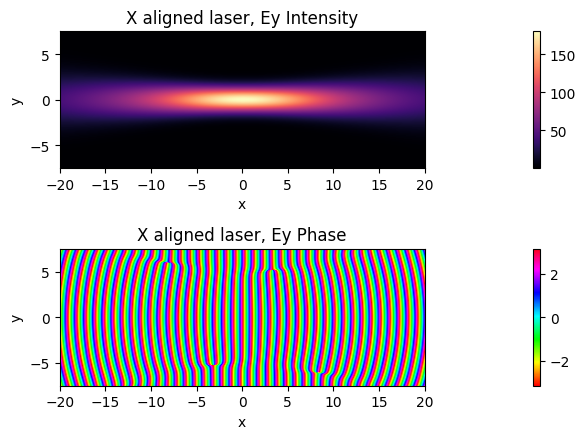

In [27]:
config.source.k_space.custom(gaussian_x,vectorised=False, sigma_x=0.75)  # bigger for higher divergence
config.source.theta_max = np.pi/2 # increasing this as well!

engine_x = wl.setup_engine(config)
fields = engine_x.compute_on_op(z=0, need_derivs=False, need_b=False)

fig = intensity_phase(fields.E[1], title=f"X aligned laser, Ey", figsize=figsize, transpose=True, extent=extent_x)
plt.show()

The reason to look at Ey is as beam is x propagating, (x frame) y is horizontal polarisation and z is vertical polarisation (by right handed requirement).
- As config's polarisation was chosen to be horizontal, Ey is the main component. 
- E is extremely small as required by paraxial limit,
- Ey is small, structured just like before (cross-polarised component) but expt_x gives a side veiw, shown below.

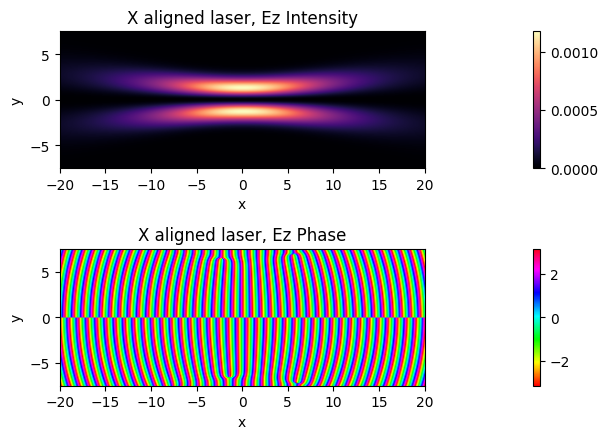

In [28]:
# Cross component, at z=0 it is vanishing so computing at z=1
fields = engine_x.compute_on_op(z=1, need_derivs=False, need_b=False)

fig = intensity_phase(fields.E[2], title=f"X aligned laser, Ez", figsize=figsize, transpose=True, extent=extent_x)
plt.show()

To see a front view of same beam, a yz grid can be manually defined and computed. A helper is defined to see all 3 components intensities and phase at once.

In [29]:
def all_components_intensity_phase(field, title=None, extent=None, figsize=(16, 9), cmap_I="magma", 
                                   cmap_P="hsv", x_label = 'x', y_label = 'y'):
    # Helper to plot intensity and phase of a complex scalar field.
    I, P = [], []
    I[:] = np.abs(field[:]) ** 2
    P[:] = np.angle(field[:])

    fig, axes = plt.subplots(2, 3, figsize=figsize)
    if title: fig.suptitle(title)

    for ax in axes.flatten():
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
    
    titles = ['Ex','Ey','Ez']
    for idx, ax in enumerate(axes[0]):
        im = ax.imshow(I[idx], cmap=cmap_I, extent=extent, origin="lower")
        ax.set_title(f"{titles[idx]} Intensity")
        fig.colorbar(im, ax=ax)

    norm = Normalize(vmin=-np.pi, vmax=np.pi)
    for idx, ax in enumerate(axes[1]):
        im = ax.imshow(P[idx], cmap=cmap_P, norm=norm, extent=extent, origin="lower")
        ax.set_title(f"{titles[idx]} Phase")

    fig.colorbar(im, ax=axes[1][2])
    
    fig.tight_layout()
    return fig


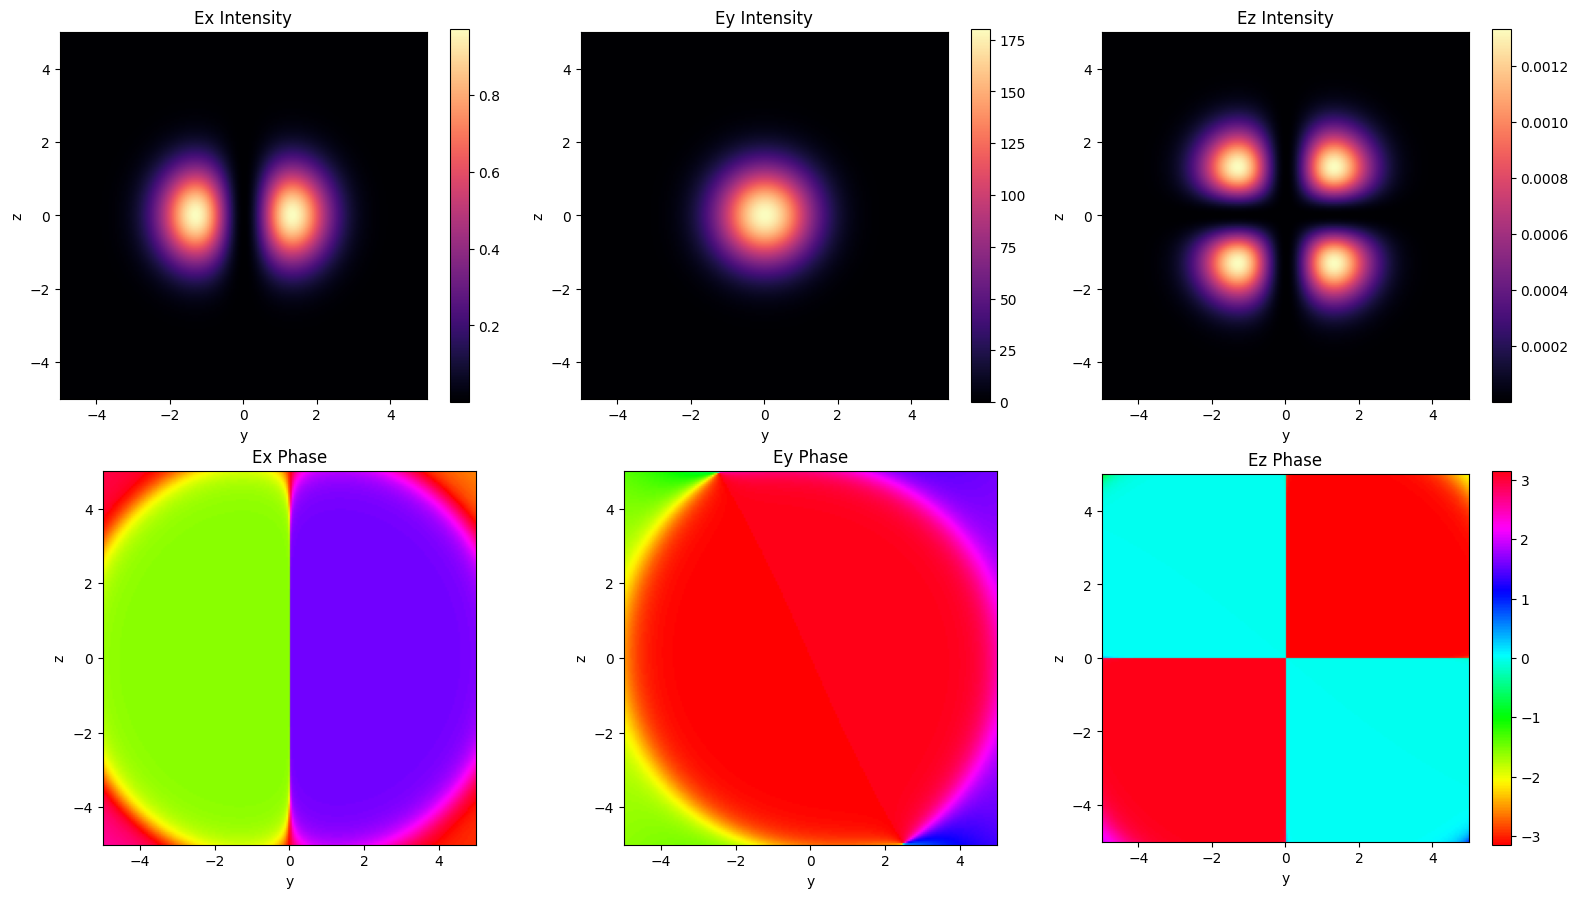

In [30]:
ny = int(10/0.05)
nz = int(10/0.05)
y = np.linspace(-5,5,ny)
z = np.linspace(-5,5,nz)
Y,Z = np.meshgrid(y,z)
X_flat = np.zeros_like(Y.flatten()) 

extent = [z.min(), z.max(), y.min(), y.max()]

fields = engine_x.compute_cloud(x_arr=X_flat,y_arr=Y.flatten(),z_arr=Z.flatten(), 
                                need_derivs=False, need_b=False)

E_grid = fields.E.reshape(3, *Y.shape)
fig = all_components_intensity_phase(E_grid,extent=extent, x_label='y', y_label='z')

The above plot cleanly shows all 3 components of x aligned beam. It is expected that a z aligned beam must be same except for the fact that
x->z, y->x, z->y  so the components cycle, so those are plot below for confirmation!

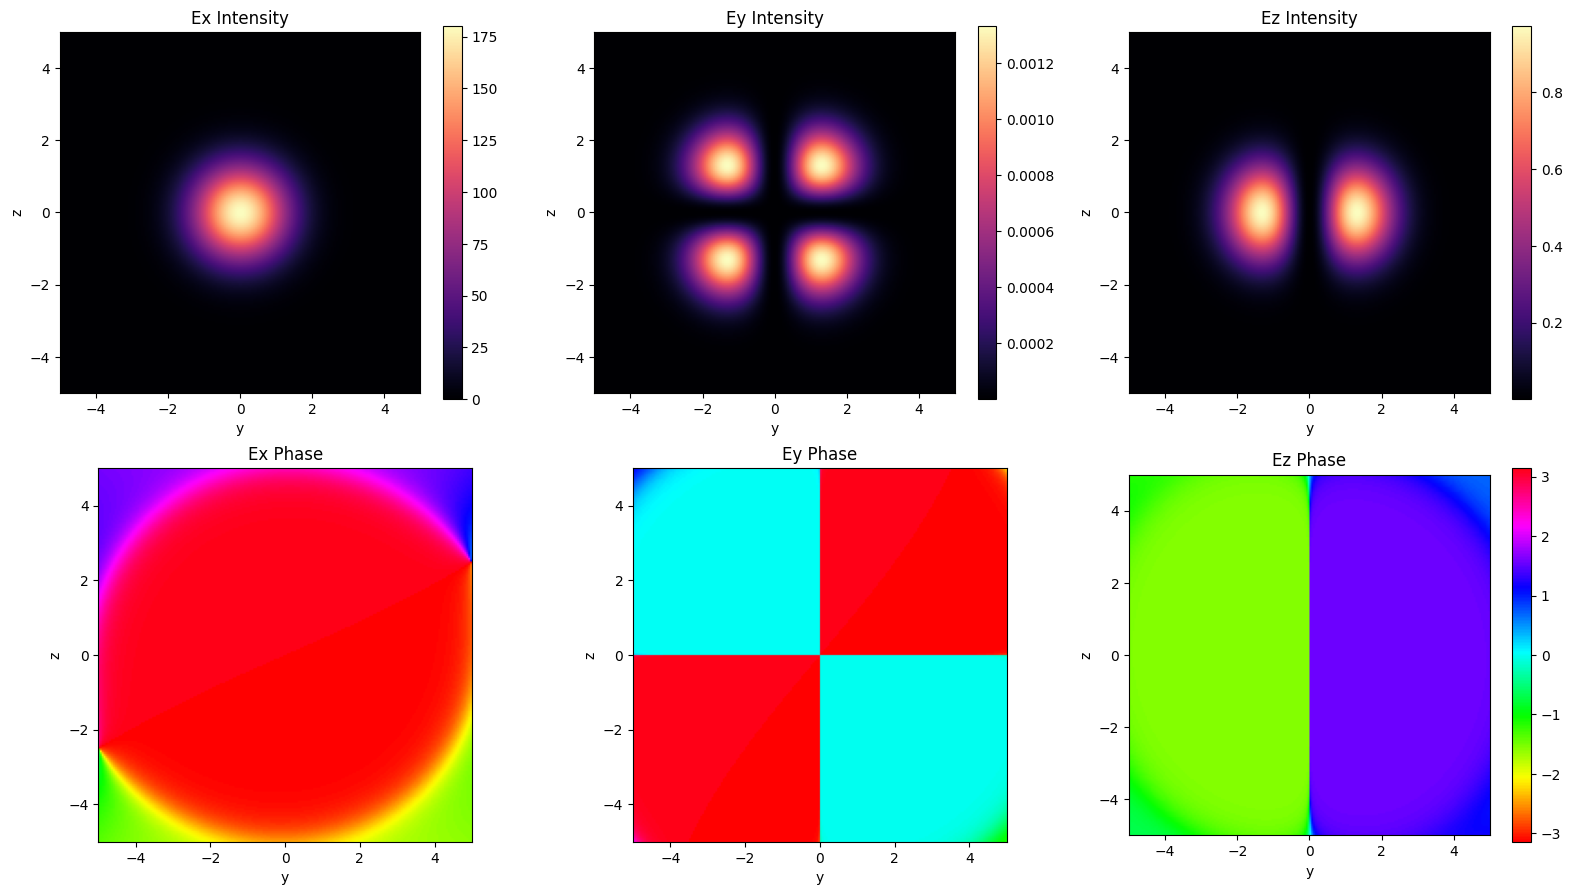

In [31]:
# comparing to inbuilt guassian, z aligned laser
config = wl.get_config()
config.source.pol_vect = (1,0)
config.source.num_modes = 10_000
config.source.k_space.gaussian(sigma_k_perp=.75)
config.source.theta_max = np.pi/2 # supporting a big sigma

config.op.size = (10,10)
config.source.randomize.off()

engine_z = wl.setup_engine(config)
fields = engine_z.compute_on_op(z=0, need_derivs=False, need_b=False)

fig = all_components_intensity_phase(fields.E,extent=engine_z.op_extent, x_label='y', y_label='z')

---
## 4. Polychromatic Experiment: Pulse


The configuration also allows defining a spectrum of wavelengths. 

Experiment 4.1: Constructing a Temporal Pulse at the Focus by simulating a broad bandwidth centered at 800nm

C:\Users\hp\Desktop\stuff\code\module_testing\wavelab\src\wavelab\config_stuff.py:570: UserWarning: Spatial aliasing detected. Grid spacing (0.05 um) is larger than half the minimum wavelength (0.0000 um).
  warnings.warn(


Scanning through time...


100%|██████████| 100/100 [00:00<00:00, 1055.25it/s]


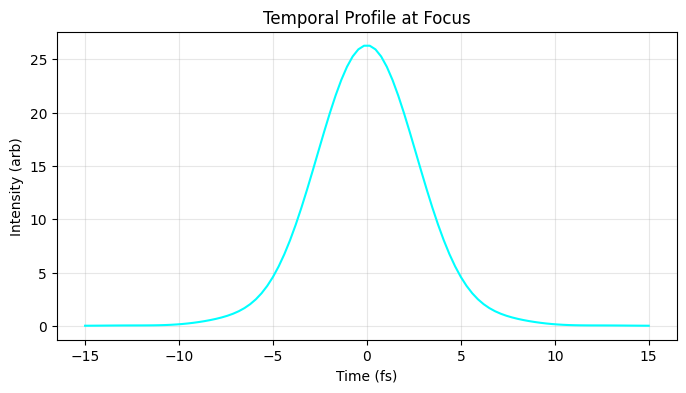

In [32]:
c = 3e8
config = wl.get_config()

# 1. Wavelengths in SI Units: 600 nm to 1000 nm
config.source.wavelength = np.linspace(600e-9, 1000e-9, 41) 

# 2. Gaussian Spectral Envelope: center 800 nm with sigma 40 nm
config.source.polychromatic.gaussian(center=800e-9, sigma=100e-9)

# 3. Gaussian Spatial Profile: k ~ 2pi/800nm = 7.8e6
# For a beam with divergence NA ~0.05, k_perp ~0.4e6.
config.source.k_space.gaussian(sigma_k_perp=4e5) 

config.source.num_modes = 50_000 # more sampling as each wavength gets ~ 1/number of wavelengths
config.source.randomize.off() 
engine = wl.setup_engine(config)

# 4. Compute Loop using compute_at_points
time_steps = np.linspace(-15e-15, 15e-15, 100)
intensities = []

print("Scanning through time...")
for t in tqdm(time_steps):
    fields = engine.compute_point(x=0, y=0, z=0, t=t*c, need_b=False, need_derivs=False)
    Ex, Ey, _ = fields.E
    I_center = np.abs(Ex)**2 + np.abs(Ey)**2
    intensities.append(I_center)

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time_steps * 1e15, intensities, color='cyan')
ax.set_xlabel('Time (fs)')
ax.set_ylabel('Intensity (arb)')
ax.set_title(f'Temporal Profile at Focus')
ax.grid(True, alpha=0.3)
plt.show()

Experiment 4.2 : Using the geometric hack from Section 3, we can visualize this pulse's movement

Simulating Monochromatic...
Simulating Polychromatic at time 0...
Simulating Polychromatic at time 1.5e-14...


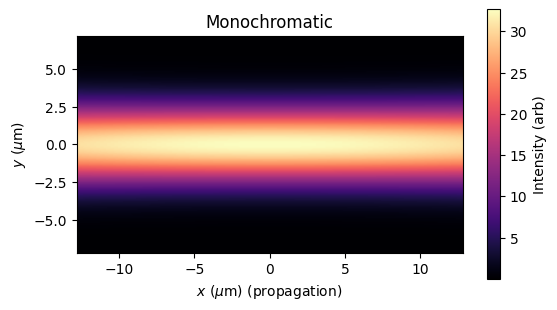

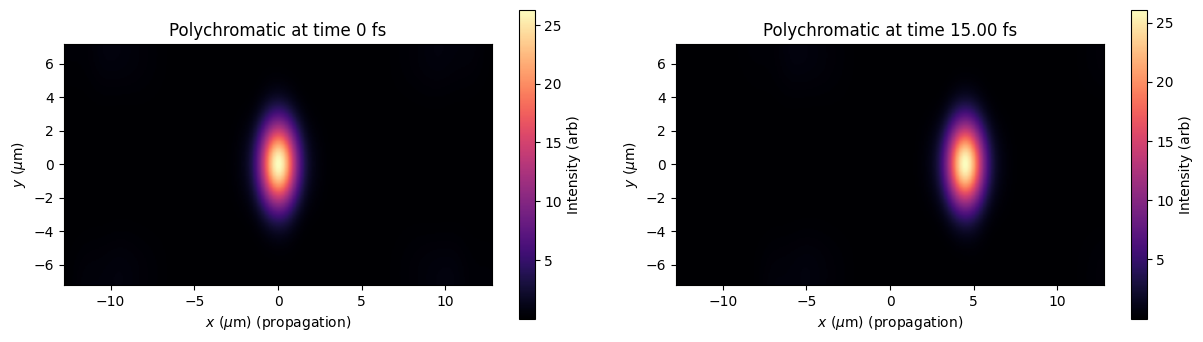

In [33]:
def visualize_side_profile(wavelengths, envelope_setup=None, title="", t=0):
    # Setup
    cfg = wl.get_config()
    
    cfg.source.beam_axis = (1, 0, 0) 
    cfg.source.theta_max = np.pi/2
    cfg.source.pol_vect = (1, 0) # Polarized in Y
    
    cfg.source.wavelength = wavelengths
    cfg.source.num_modes = 50_000 
    cfg.source.randomize.off() 
    
    cfg.source.k_space.custom(gaussian_x, vectorised=True, sigma_x=4e5)
    
    if envelope_setup:
        envelope_setup(cfg)
        
    scale = np.mean(wavelengths)*2
    cfg.op.size = (16*scale,9*scale)     
    cfg.op.spacing = 0.05*scale
    cfg.op.center = (0, 0)

    print(f"Simulating {title}...")
    eng = wl.setup_engine(cfg)
    
    # Compute at t=c*time
    E = eng.compute_on_op(z=0, t=c*t, need_derivs=False, need_b=False).E
    
    extent_um = [eng.x.min()*1e6, eng.x.max()*1e6, eng.y.min()*1e6, eng.y.max()*1e6]
    return np.abs(E[1])**2, extent_um

# 1. Monochromatic (Same as section 3, done here for comparision)
I_mono, ext = visualize_side_profile(wavelengths=800e-9, title="Monochromatic")

# 2. Polychromatic (Bullet)
def setup_poly(cnf:wl.Config):
    cnf.source.polychromatic.gaussian(center=800e-9, sigma=100e-9)

I_poly, ext = visualize_side_profile(wavelengths=np.linspace(600e-9, 1000e-9, 41),envelope_setup=setup_poly,title="Polychromatic at time 0")

# Time evolution
t = 15e-15
I_poly_t, ext_t = visualize_side_profile(wavelengths=np.linspace(600e-9, 1000e-9, 41),envelope_setup=setup_poly,title=f"Polychromatic at time {t}",t = t)

# 3. Plotting
def imshow_helper(fig, ax, data, *,extent,title,
                     xlabel=r'$x\ (\mu\mathrm{m})$ (propagation)',ylabel=r'$y\ (\mu\mathrm{m})$',
                     cmap='magma',cbar_label='Intensity (arb)'):
    im = ax.imshow(data, cmap=cmap, extent=extent, origin='lower')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)

    return im

fig1, ax1 = plt.subplots(figsize=(16/9*3.5, 3.5))
imshow_helper(fig1, ax1, I_mono,extent=ext,title="Monochromatic")
plt.show()

fig2, (ax2, ax3) = plt.subplots(1, 2, figsize=(2*16/9*3.5, 3.5))

imshow_helper(fig2, ax2, I_poly,extent=ext,title="Polychromatic at time 0 fs")
imshow_helper(fig2, ax3, I_poly_t,extent=ext_t,title=f"Polychromatic at time {t*1e15:.2f} fs")

plt.tight_layout()
plt.show()

As expected, the monochromatic beam is continous and the polychromatic beam is a pulse moving in x direction with time.

In [34]:
print('Total time to render', time.time()-start)

Total time to render 77.2130184173584
